In [1]:
from matplotlib import cm
from netCDF4 import Dataset 
import numpy as np 
import math
import scipy.stats as stats 
import matplotlib.pyplot as plot
from matplotlib.pyplot import MultipleLocator
from scipy import signal
# import seaborn
import seaborn as sns
import datetime
import calendar
from sklearn import preprocessing

In [2]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/ur60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(ubp.shape)

#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/tr60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/tb60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

tref = ncin1.variables['tref'] 
tref = (np.array(tref))
tbar = ncin2.variables['tbar'] 
tbar = (np.array(tbar))
print(tref.shape)
print(tbar.shape)

i=0
trp = np.zeros((42,992))
tbp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tref[j,month[m],i]!=0:
                    trp[i,k] = tref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if tref[j,month[m],i+1]!=0:
                    trp[i,k] = tref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if tbar[j,month[m],i]!=0:
                    tbp[i,k] = tbar[j,month[m],i]
                    k=k+1
            else:
                if tbar[j,month[m],i+1]!=0:
                    tbp[i,k] = tbar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


print(tbp.shape)


dmax = 716

ueast = np.zeros((42,dmax))
ratiosl = np.zeros((42,dmax))

onset = np.zeros((42,dmax))
ronset = np.zeros((42,dmax))

onset_id = np.zeros(200)
ronset_id = np.zeros(210)

end = np.zeros((42,dmax))
rend = np.zeros((42,dmax))

end_id = np.zeros(200)
rend_id = np.zeros(210)

ssw = np.zeros((42,dmax))
rssw = np.zeros((42,dmax))

fponset_id = np.zeros(210)

ratio = 0.3

######################################### find out the onset date #######################################

i = 0
while(i < 42):
    j = 0
    while(j < dmax):
        if ubp[i,j] < 0:
            ueast[i,j] = 1 
        if ubp[i,j]/urp[i,j] < ratio:
            ratiosl[i,j] = 1
        j=j+1
    i=i+1

i = 0
n = 0
nn = 0
m = 0
mm = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):
        if ubp[i,j] < 0 and ueast[i,j-1] == 0:
            onset[i,j] = 1
            onset_id[n] = t
            n=n+1
            #print(date[i][j])
        elif ubp[i,j] > 0 and ueast[i,j-1] == 1:
            end[i,j] = 1
            end_id[m] = t
            m=m+1
        elif j == dmax-1:
            if ueast[i,j] == 1:
                end[i,j] = 1
                end_id[m] = t
                m=m+1
        if ubp[i,j]/urp[i,j] < ratio and ratiosl[i,j-1] == 0: 
            ronset[i,j] = 1
            ronset_id[nn] = t
            nn=nn+1
        elif ubp[i,j]/urp[i,j] > ratio and ratiosl[i,j-1] == 1: 
            rend[i,j] = 1
            rend_id[mm] = t
            mm=mm+1
        elif j == dmax-1:
            if ratiosl[i,j] == 1:
                rend[i,j] = 1
                rend_id[mm] = t
                mm=mm+1
        t=t+1
        j=j+1
    i=i+1


######################################### exclude some events #######################################

n = 1
while(n<210):
    if rend_id[n]-ronset_id[n]<2*4:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1


#the interval of the start of an event and the end of the last event should be larger than 10 days
n = 1
while(n<200):
    if (onset_id[n]-end_id[n-1])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1 
n = 2
while(n<200):
    if (onset_id[n]-end_id[n-2])<10*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 1
while(n<210):
    if (ronset_id[n]-rend_id[n-1])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1 
n = 2
while(n<210):
    if (ronset_id[n]-rend_id[n-2])<10*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

#there shouldn't be a new event shorter than 20 days
n = 1
while(n<200):
    if onset_id[n]-onset_id[n-1]<20*4:
        onset_id[n]=0
        end_id[n]=0
    n=n+1

n = 3
while(n<210):
    if ronset_id[n]-ronset_id[n-3]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1

n = 2
while(n<210):
    if ronset_id[n]-ronset_id[n-2]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1
    
n = 1
while(n<210):
    if ronset_id[n]-ronset_id[n-1]<20*4:
        ronset_id[n]=0
        rend_id[n]=0
    n=n+1  

#the event lasts till the end should be excluded
n = 1
while(n<200):
    if end_id[n]%(dmax-1)==0:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

n = 1
while(n<210):
    if rend_id[n]%(dmax-1)==0:
        ronset_id[n]=0
        rend_id[n]=0        
    n=n+1

#an event should at least be longer than 2 days
n = 1
while(n<200):
    if end_id[n]-onset_id[n]<2*4:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1


#exclude 3 events
n = 1
while(n<200):
    if onset_id[n]==6380 or onset_id[n]==18525 or onset_id[n]==22145:
        onset_id[n]=0
        end_id[n]=0        
    n=n+1

    
fp=0
tp=0
fn=0
fpb=0

######################################### print out the date #######################################

barplot = np.zeros(6)

i = 0
n = 0
c = 0
while(i < 42):
    j = 1
    while(j < dmax):
        if onset[i,j] == 1:      #ubar<0
            if onset_id[n] == 0: #ubar<0 but there's no SSW
                True
            else:                #there is an SSW
                print(date[i][j])
                
                if date[i][j][5:7] == '11':
                    barplot[0] = barplot[0]+1
                elif date[i][j][5:7] == '12':
                    barplot[1] = barplot[1]+1
                elif date[i][j][5:7] == '01':
                    barplot[2] = barplot[2]+1
                elif date[i][j][5:7] == '02':
                    barplot[3] = barplot[3]+1                    
                elif date[i][j][5:7] == '03':
                    barplot[4] = barplot[4]+1                     
                elif date[i][j][5:7] == '04':
                    barplot[5] = barplot[5]+1                     
                
                if ubp[i,j-2]/urp[i,j-2] < ratio: #find out true positive
                    tp=tp+1
#                if ubp[i,j]/urp[i,j] > ratio: #find out false negative
#                    fn=fn+1                
                c=c+1            #how many SSWs
            n=n+1                #the size of onset_id        
        j=j+1
    i=i+1

print('####################################')

i = 0
nn = 0
cc = 0
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1:      #ubar/uref<0.3
            if ronset_id[nn] == 0: #ubar/uref<0.3 but there's no SSW
                True
            else:
                #print(date[i][j])
                cc=cc+1            #how many rSSWs
            nn=nn+1                #the size of onset_id       
        j=j+1
    i=i+1


    
######################################### mark each day of ssw #######################################
i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax):       
        if t>=onset_id[n] and t<=end_id[n]:
            ssw[i,j] = 1
        if end[i,j]==1:
            n=n+1                #the size of onset_id   
        if t>=ronset_id[nn] and t<=rend_id[nn]:
            rssw[i,j] = 1
        if rend[i,j]==1:
            nn=nn+1                #the size of onset_id  
        t=t+1
        j=j+1
    i=i+1
    
print('####################################')
######################################### find out false positive #######################################
nn = 0
fponset_id=ronset_id
while(nn < 210):
    n = 0
    while(n < 200):
        if onset_id[n]>ronset_id[nn] and onset_id[n]<rend_id[nn]: #exclude onset happen between <0.3 start and end
            fponset_id[nn]=0
        elif abs(onset_id[n]-ronset_id[nn])<40: #exclude 0.3 and onset too far way
            fponset_id[nn]=0
        n=n+1
    nn=nn+1

i = 0
n = 0
nn = 0
t = 1
while(i < 42):
    j = 1
    while(j < dmax): 
        if ronset[i,j] == 1: 
            if fponset_id[nn] != 0:      #ubar/uref<0.3
                fp=fp+1
                if ubp[i,j+5]<ubp[i,j]:
                    fpb=fpb+1
            nn=nn+1
        j=j+1
    i=i+1


print('true positive:'+str(tp))
print('total ssws amount:'+str(c))
print('false positive:'+str(fp))
print('false positive but vortex decreasing:'+str(fpb))




height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

filename1 = '/scratch/smliu01/1d_model/archive/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))


filename1 = '/scratch/smliu01/1d_model/archive/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/scratch/smliu01/1d_model/archive/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb

uref_eachyr = Oct_to_May(uref)
ubar_eachyr = Oct_to_May(ubar)
fawa_eachyr = Oct_to_May(fawa)
epz_eachyr = Oct_to_May(epz)


print('done')




(124, 12, 43)
(124, 12, 43)
(42, 992)
(124, 12, 43)
(124, 12, 43)
(42, 992)
1980/02/29/00
1981/12/04/00
1984/02/23/18
1984/12/31/18
1987/01/22/18
1987/12/08/00
1989/02/21/00
1998/12/15/06
1999/02/25/18
2000/03/19/18
2001/02/11/06
2001/12/30/12
2004/01/04/18
2006/01/21/00
2007/02/24/00
2008/02/21/18
2009/01/24/06
2010/02/09/00
2013/01/06/12
2018/02/11/18
2019/01/19/18
2021/01/05/00
####################################
####################################
true positive:22
total ssws amount:22
false positive:44
false positive but vortex decreasing:39
48000.0
10000.0
(97, 124, 12, 43)
(97, 124, 12)
done


In [3]:
model = 'ens00'

In [4]:
#file = '/scratch/smliu01/1d_model/output_sweep/scale_1p00/'+model+'/uout_scale_1p00_'+model+'.nc'
# file = '/scratch/smliu01/1d_model/climatechange/forcing/ctl/uout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
file = '/scratch/smliu01/1d_model/ens10_1k_control_output/scale_1p00/ens01/uout_scale_1p00_ens01.nc'
#file = '/nas/smliu01/1d_model/output_sweep/scale_1p00/ens00/uout_scale_1p00_ens00.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
ubar = ncin.variables['ubar']
ubar = np.array(ubar)
ncin.close()
print(ubar.shape)

#file = '/scratch/smliu01/1d_model/output_sweep/scale_1p00/'+model+'/aout_scale_1p00_'+model+'.nc'
#file = '/scratch/smliu01/1d_model/climatechange/forcing/ctl/aout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
file = '/scratch/smliu01/1d_model/ens10_1k_control_output/scale_1p00/ens01/aout_scale_1p00_ens01.nc'
# file = '/nas/smliu01/1d_model/output_sweep/scale_1p00/ens00/aout_scale_1p00_ens00.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fawa = ncin.variables['fawa']
fawa = np.array(fawa)
ncin.close()
print(fawa.shape)

#file = '/scratch/smliu01/1d_model/output_sweep/scale_1p00/'+model+'/urout_scale_1p00_'+model+'.nc'
# file = '/scratch/smliu01/1d_model/climatechange/forcing/ctl/urout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
file = '/scratch/smliu01/1d_model/ens10_1k_control_output/scale_1p00/ens01/urout_scale_1p00_ens01.nc'
# file = '/nas/smliu01/1d_model/output_sweep/scale_1p00/ens00/urout_scale_1p00_ens00.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
uref = ncin.variables['uref']
uref = np.array(uref)
ncin.close()
print(uref.shape)

#file = '/scratch/smliu01/1d_model/output_sweep/scale_1p00/'+model+'/fzout_scale_1p00_'+model+'.nc'
# file = '/scratch/smliu01/1d_model/climatechange/forcing/ctl/fzout_b0p23s0p5_d5_u7p0f16p0_a0p40_c2p200E-03_p2p5_ep300.nc'
file = '/scratch/smliu01/1d_model/ens10_1k_control_output/scale_1p00/ens01/fzout_scale_1p00_ens01.nc'
# file = '/nas/smliu01/1d_model/output_sweep/scale_1p00/ens00/fzout_scale_1p00_ens00.nc'
ncin = Dataset(file, 'r', format='NETCDF4')
fz = ncin.variables['fz']
fz = np.array(fz)
ncin.close()
print(fz.shape)

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(381)
dz = 500.
hh = 7000.
dz1d = 100
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(381):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

hhh = np.arange(0,501,1)*0.2+10.

yr = 1000   # 42 for 42 years, 10 for 10 years

# # Reshape ubar, fawa, uref to (1001, 42, 320)
ubar_eachyear = ubar.reshape((501, yr, 160))
fawa_eachyear = fawa.reshape((501, yr, 160))
uref_eachyear = uref.reshape((501, yr, 160))
fz_eachyear = fz.reshape((501, yr, 160))

for i in range(501):
    fz_eachyear[i,:,:] = fz_eachyear[i,:,:]#/np.exp(-hhh[i]*1000/hh)


(501, 160000)
(501, 160000)
(501, 160000)
(501, 160000)
48000.0
10000.0


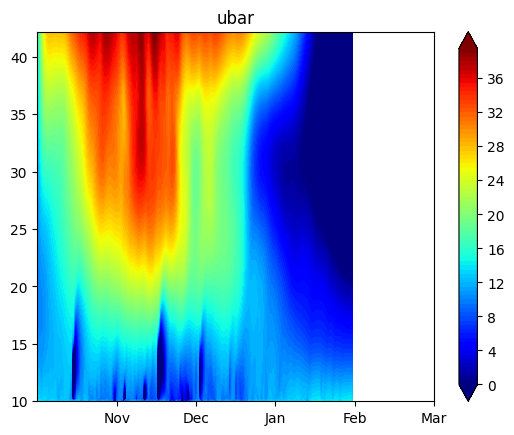

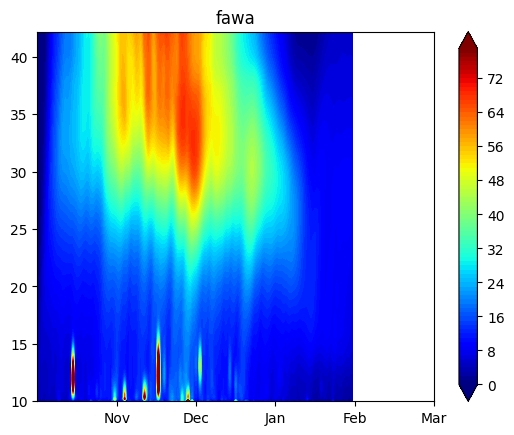

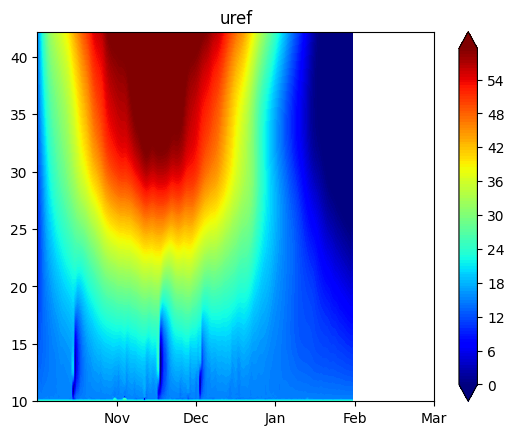

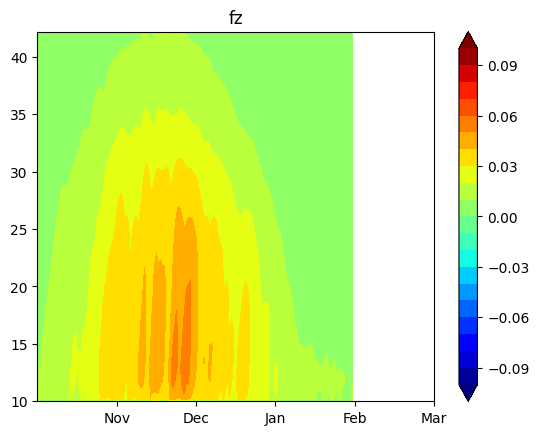

In [5]:
xx = np.arange(0,160,1) #*int(992/320)/4
zz = hhh

fig, ax = plot.subplots()
cf = ax.contourf(xx, zz[0:162], np.mean(ubar_eachyear[0:162,:,], axis=1), levels=np.arange(0, 40, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('ubar')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()   
cf = ax.contourf(xx,zz[0:162],np.mean(fawa_eachyear[0:162,:,:],axis=1), levels=np.arange(0, 80, 1), extend='both',cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fawa')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx,zz[0:162],np.mean(uref_eachyear[0:162,:,],axis=1), levels=np.arange(0, 60, 0.5), extend='both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('uref')
plot.colorbar(cf, ax=ax)
plot.show()

fig, ax = plot.subplots()
cf = ax.contourf(xx,zz[0:162],np.mean(fz_eachyear[0:162,:,:],axis=1), levels=np.arange(-0.1, 0.11, 0.01),extend= 'both', cmap='jet')
ax.set_xticks([40,80,120,160,200])
ax.set_xticklabels(['Nov', 'Dec', 'Jan', 'Feb', 'Mar'])
ax.set_title('fz')
plot.colorbar(cf, ax=ax)
plot.show()


In [6]:
import numpy as np

def model_ubar_to_era5_like_inputs(
    ubar_model,          # shape = (nz, years*steps_per_year)  (501, 13440)
    level_index=110,     # 100 hPa  z 
    years=yr, # 200,
    steps_per_year=160,  #  10–5 
    start_year=1979      #  ERA5  1979-10 
):
    """
    
      ubp:  shape = (years, 992)  6-hourly Oct–May 
      date: list[list[str]]'YYYY/MM/DD/HH' ubp 
    
      -  992 = 8  × 31  × 4 /
      - ['10','11','12','01','02','03','04','05']
         31 2  31 
         31×4=124  0 
      -  SSW 
    """
    nz, nt = ubar_model.shape
    assert nt == years * steps_per_year, " years*steps_per_year "

    #  100 hPa  reshape  (years, steps_per_year)
    u = np.array(ubar_model[level_index, :], dtype=float).reshape(years, steps_per_year)

    #  6-hourly  992 8  × 31  ×  4 
    tgt_len = 992
    src_x = np.arange(steps_per_year, dtype=float)
    tgt_x = np.linspace(0, steps_per_year - 1, tgt_len)

    ubp = np.empty((years, tgt_len), dtype=float)
    for y in range(years):
        #  1D 
        ubp[y] = np.interp(tgt_x, src_x, u[y])

    #  date list of list
    time4 = ['00', '06', '12', '18']
    months = ['10', '11', '12', '01', '02', '03', '04', '05']
    days31 = [f"{d:02d}" for d in range(1, 32)]  #  31 
    #  8  × 31  × 4 / = 992
    date = [[None]*tgt_len for _ in range(years)]
    for y in range(years):
        k = 0
        for mi, mm in enumerate(months):
            # 10/11/12  start_year+y01–05  start_year+y+1
            year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
            for dd in days31:
                for hh in time4:
                    #  'YYYY/MM/DD/HH'
                    date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                    k += 1
        assert k == tgt_len

    return ubp, date

# =====  =====
ubp_model, date_model = model_ubar_to_era5_like_inputs(ubar, level_index=110, years=yr, steps_per_year=160, start_year=1979)
#  ubp_model  ubp shape=(42,992)date_model 
#  uref urp_model


In [7]:
import numpy as np

def count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=716,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=10.0,
    use_djf_only=False,
    exclude_onset_indices=None,
    #  date 
    date_2d=None,
    #  3  10  onset 
    enforce_march10_cutoff=False,
    return_debug=False,
):
    """
     10 hPa u<0  SSW 

    
    -  enforce_march10_cutoff=True  date_2d
       onset  3  10 
    """

    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    # =====  →  =====
    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    # ===== DJF only  =====
    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    # ===== 1.  u<0  =====
    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    # ===== 2.  >= 2  &  =====
    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    # ===== 3. / end  10  & onset-onset  20  =====
    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end    = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset  = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))
        else:
            pass  #  onset_id[n]=0, end_id[n]=0

    # ===== 4.  onset 6380, 18525, 22145  =====
    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1  #  t  1 
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    # ===== 5. onset  3  10  =====
    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])   #  'YYYY-MM-DD...' 
            mm = int(dstr[5:7])
            dd = int(dstr[8:10])

            #  3  10  month>3  (month==3  day>10)
            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


import numpy as np

# ===== 0.  =====
dmax  = 992         #  dmax
years = yr #200          #  42 
n_per_year = dmax   # 

# ubp: shape (42, dmax)  10 hPa ubar
# date: shape (42, dmax) 

# ===== 1.  ubar  1D =====
u_all_flat = ubp_model.reshape(-1)   #  flatten 0  1 ...

#  3 
#  exclude_onset_indices=None
exclude_list = [6380, 18525, 22145]

n_ssw, events, debug = count_ssw_events_from_ubar_legacy(
    u_all_flat,
    n_per_year=dmax,
    years=years,
    dmax_ref=dmax,
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    use_djf_only=False,
    exclude_onset_indices= None,  # 
    date_2d=date_model,                 # 
    enforce_march10_cutoff=True,  #  3  10 
    return_debug=True,
)

print("total ssws amount:", n_ssw)

# ===== 2.  =====

#  2D 
ueast = np.zeros((years, dmax))   # 
onset = np.zeros((years, dmax))
end   = np.zeros((years, dmax))
ssw   = np.zeros((years, dmax))

# 
onset_id = np.zeros(1000)   #  200
end_id   = np.zeros(1000)

#  barplot 11,12,01,02,03,04
barplot = np.zeros(6)

#  events (0-based  (start_idx, end_idx))  onset/onset_id/ssw 
for k, (s, e) in enumerate(events):
    # s,e  flatten 0..years*n_per_year-1
    #  (, )
    i_s = s // dmax   #  index
    j_s = s %  dmax   # 
    i_e = e // dmax
    j_e = e %  dmax

    # 
    onset[i_s, j_s] = 1
    end[i_e, j_e]   = 1

    #  1-based  onset_id / end_id
    #  while  t=1,2,... 
    if k+1 < onset_id.size:
        onset_id[k+1] = s + 1   # 1-based
    if k+1 < end_id.size:
        end_id[k+1]   = e + 1

    # =====  date[i][j]  barplot  =====
    cur_date = date_model[i_s][j_s]   # onset 
    mm = cur_date[5:7]          # 'YYYY-MM-DD' → 'MM'
    if   mm == '11':
        barplot[0] += 1
    elif mm == '12':
        barplot[1] += 1
    elif mm == '01':
        barplot[2] += 1
    elif mm == '02':
        barplot[3] += 1
    elif mm == '03':
        barplot[4] += 1
    elif mm == '04':
        barplot[5] += 1

    # =====  ssw[i,j] =====
    for tt in range(s, e+1):
        ii = tt // dmax
        jj = tt %  dmax
        ssw[ii, jj] = 1

# ===== 3.  =====

print('####################################')
#  onset 
for (s, e) in events:
    i_s = s // dmax
    j_s = s %  dmax
    print(date_model[i_s][j_s])

print('####################################')
print('barplot (11,12,01,02,03,04):', barplot)
print('total ssws amount:', n_ssw)


total ssws amount: 612
####################################
1980/02/12/06
1981/03/04/18
1983/03/04/18
1986/02/23/12
1987/01/25/18
1987/02/29/06
1989/02/23/12
1990/03/08/00
1991/03/04/00
1992/02/08/18
1992/10/24/06
1995/01/26/00
1995/02/27/18
1995/12/30/00
1997/03/03/00
1998/02/07/06
2000/02/20/12
2003/02/07/06
2004/02/05/06
2005/02/25/00
2006/03/06/06
2007/02/17/06
2008/02/20/00
2009/02/20/00
2010/02/07/12
2013/03/04/06
2018/03/05/00
2019/03/10/06
2019/10/22/18
2020/03/01/06
2023/02/24/00
2024/03/05/00
2027/03/01/00
2028/03/06/18
2031/01/28/00
2031/03/03/12
2036/02/15/00
2039/10/22/06
2042/02/29/00
2043/03/04/00
2045/10/27/12
2048/03/09/12
2048/10/27/06
2050/10/11/18
2051/12/09/00
2053/01/30/12
2054/03/04/00
2055/01/14/12
2055/02/11/00
2057/02/18/12
2058/02/24/12
2059/02/28/06
2060/10/08/12
2061/03/05/06
2068/10/14/00
2071/02/22/06
2072/02/22/00
2072/10/25/12
2075/12/19/12
2078/02/01/12
2081/02/19/12
2083/01/26/18
2084/01/04/06
2088/03/09/06
2088/12/09/12
2089/12/25/00
2095/02/23/12
20

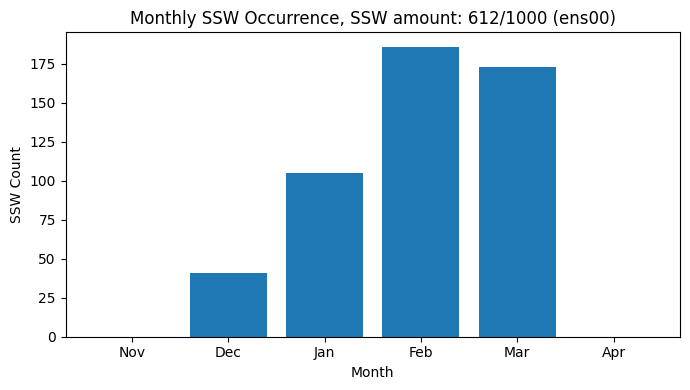

In [8]:
import matplotlib.pyplot as plt
months = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr']
plt.figure(figsize=(7,4))
plt.bar(months, barplot)
plt.xlabel('Month')
plt.ylabel('SSW Count')
plt.title('Monthly SSW Occurrence, SSW amount: ' + str(n_ssw)+'/1000' + ' ('+model+')')
plt.tight_layout()
plt.show()


In [9]:
from scipy.interpolate import interp1d

# Assume the last dimension of *_eachyear is the one to interpolate (e.g., 320 -> 992)
target_len = 992

# --- FAWA ---
orig_len_fawa = fawa_eachyear.shape[2]
x_orig_fawa = np.linspace(0, 1, orig_len_fawa)
x_new = np.linspace(0, 1, target_len)

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_fawa, fawa_eachyear[110, i, :], kind='linear')
    fawa_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(fawa_interp, label='2023 ver.')
#     ax.plot(fawa_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('FAWA at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

# --- UBAR ---
orig_len_ubar = ubar_eachyear.shape[2]
x_orig_ubar = np.linspace(0, 1, orig_len_ubar)
# x_new is already defined above

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_ubar, ubar_eachyear[110, i, :], kind='linear')
    ubar_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(ubar_interp, label='2023 ver.')
#     ax.plot(ubar_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('UBAR at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

# --- UREF ---
orig_len_uref = uref_eachyear.shape[2]
x_orig_uref = np.linspace(0, 1, orig_len_uref)
# x_new is already defined above

# fig, axes = plot.subplots(6, 7, figsize=(20,12), sharex=True, sharey=True)
# axes = axes.flatten()

for i in range(yr):
    interp_func = interp1d(x_orig_uref, uref_eachyear[110, i, :], kind='linear')
    uref_interp = interp_func(x_new)
#     ax = axes[i]
#     ax.plot(uref_interp, label='2023 ver.')
#     ax.plot(uref_eachyr[64, i, :], label='ERA5')
#     ax.set_title(f'{1979+i}')
#     if i == 0:
#         ax.legend(fontsize='small')
# for j in range(yr, len(axes)):
#     axes[j].axis('off')
# fig.suptitle('UREF at 10 hPa', fontsize=16)
# fig.tight_layout(rect=[0, 0.03, 1, 0.97])
# plot.show()

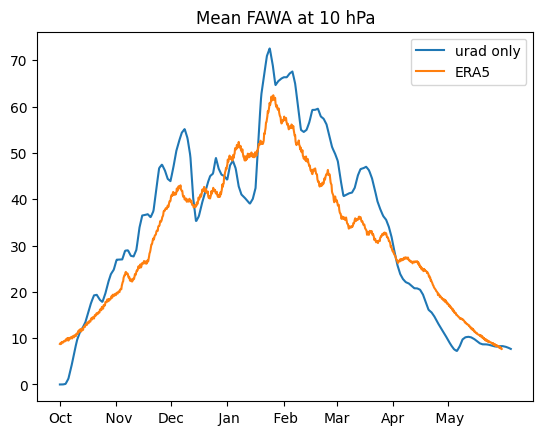

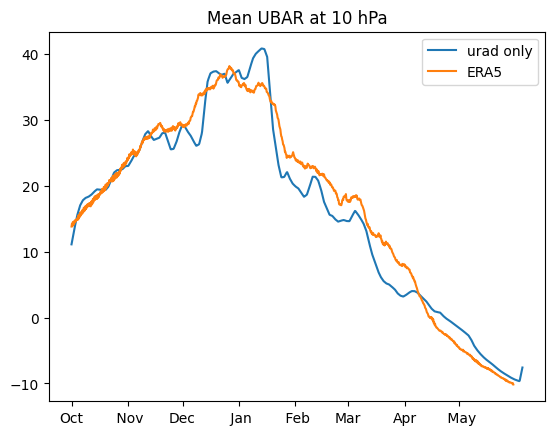

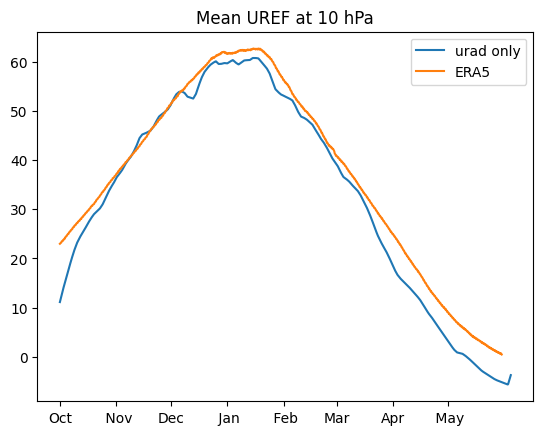

In [10]:
# Plot the mean over axis=1 for fawa, ubar, and uref (both _eachyear and _eachyr)
# For *_eachyear, interpolate the mean as well

x = np.arange(0,992,1)/4

# FAWA
fawa_eachyear_mean = np.mean(fawa_eachyear[110, 0:40, :], axis=0)
interp_func_fawa = interp1d(x_orig_fawa, fawa_eachyear_mean, kind='linear')
fawa_eachyear_mean_interp = interp_func_fawa(x_new)
fawa_eachyr_mean = np.mean(fawa_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,fawa_eachyear_mean_interp, label='urad only')
plot.plot(x,fawa_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean FAWA at 10 hPa')
plot.show()

# UBAR
ubar_eachyear_mean = np.mean(ubar_eachyear[110, 0:40, :], axis=0)
interp_func_ubar = interp1d(x_orig_ubar, ubar_eachyear_mean, kind='linear')
ubar_eachyear_mean_interp = interp_func_ubar(x_new)
ubar_eachyr_mean = np.mean(ubar_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,ubar_eachyear_mean_interp, label='urad only')
plot.plot(x,ubar_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean UBAR at 10 hPa')
plot.show()

# UREF
uref_eachyear_mean = np.mean(uref_eachyear[110, 0:40, :], axis=0)
interp_func_uref = interp1d(x_orig_uref, uref_eachyear_mean, kind='linear')
uref_eachyear_mean_interp = interp_func_uref(x_new)
uref_eachyr_mean = np.mean(uref_eachyr[64, 0:40, :], axis=0)

plot.figure()
plot.plot(x,uref_eachyear_mean_interp, label='urad only')
plot.plot(x,uref_eachyr_mean, label='ERA5')
plot.xticks(ticks=[0,31,61,92,123,152,183,213], labels=['Oct',' Nov', 'Dec',' Jan',' Feb', 'Mar', 'Apr',' May'])
plot.legend()
plot.title('Mean UREF at 10 hPa')
plot.show()

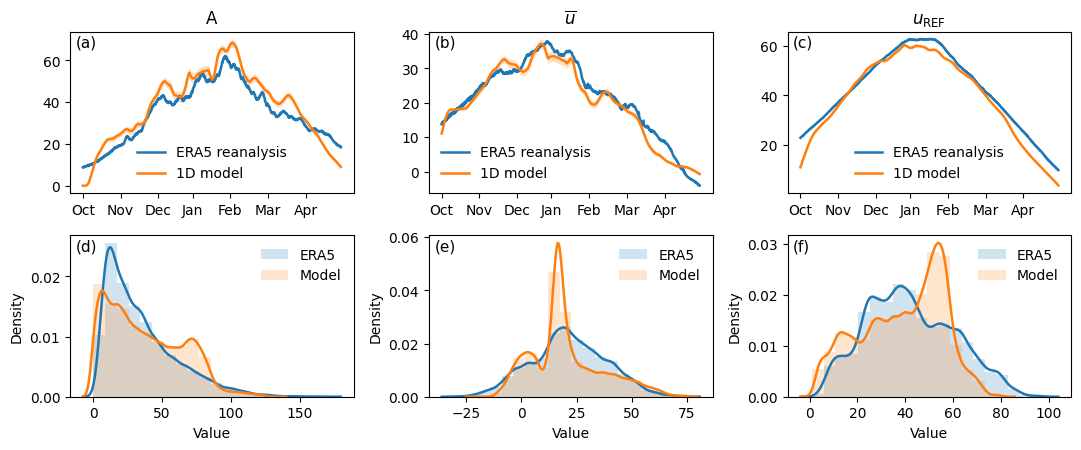

[INFO] ERA5 DJF points: 848 of 992
[INFO] FAWA model time len: 160 DJF points: 137
[INFO] UBAR model time len: 160 DJF points: 137
[INFO] UREF model time len: 160 DJF points: 137
[INFO] x_days_fawa range: 0.0 -> 211.91194968532267
[INFO] x_days_ubar  range: 0.0 -> 211.91194968532267
[INFO] x_days_uref  range: 0.0 -> 211.91194968532267


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ———  import seaborn ———
try:
    import seaborn as sns
    HAS_SNS = True
except Exception:
    HAS_SNS = False

from scipy.interpolate import interp1d
import os

# ======================
# 0) 
# ======================
# ERA56 -> 992  Oct1(0d) ~ May  247.75d
x = np.arange(0, 992, 1) / 4.0  #  Oct 1 
T_days = x.max()                # 247.75
# DJF  Oct1  0
# DEC1 = 31 + 30               # 61
# MAR1 = DEC1 + 31 + 31 + 28    # 151

DEC1 = 0               # 61
MAR1 = 31 + 30 + 31 + 31 + 28 + 31 + 30   # 151

#  x_orig_* None
x_orig_fawa = globals().get("x_orig_fawa", None)
x_orig_ubar = globals().get("x_orig_ubar", None)
x_orig_uref = globals().get("x_orig_uref", None)

# ==========  + (yrs,time) DJF  ==========
def _auto_time_coord(n_time, x_orig_like):
    """
     time Oct1  n_time
    
    1) · ~ 0..~248 -> 
    2)  0..n_time-1          ->  0..T_days
    3)  0..1                ->  T_days
    min..max -> 0..T_days
    """
    if x_orig_like is None:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    x_arr = np.asarray(x_orig_like, dtype=float)
    if x_arr.size != n_time:
        # 
        idx = np.linspace(0, 1, n_time)
        return idx * T_days

    # 
    x_min, x_max = float(np.nanmin(x_arr)), float(np.nanmax(x_arr))
    span = x_max - x_min + 1e-12

    # 1)  0..~248
    if x_max >= 200 and x_max <= 400 and x_min > -5:
        #  0..~248 
        #  0  [0, x_max-x_min]
        x_days = x_arr - x_min
        #  ERA5 
        x_days = (x_days / (x_days.max() + 1e-12)) * T_days
        return x_days

    # 2)  0..1
    if x_min >= -1e-6 and x_max <= 1.0 + 1e-6:
        return (x_arr - x_min) / span * T_days

    # 3)  0..n_time-1
    if x_min >= -1e-6 and abs(x_max - (n_time - 1)) < 1e-6:
        return (x_arr - x_min) / span * T_days

    #  0..T_days
    return (x_arr - x_min) / span * T_days


def _djf_mask_from_days(x_days):
    """Oct1  DJF(Dec1~Mar1) """
    return (x_days >= DEC1) & (x_days < MAR1)


def _subseries_DJF(year_time_array, x_orig_like=None):
    """
    year_time_array  (years, time)
         x_orig_like        time /
    
      arr_DJF: (years, time_djf)
      x_sub :  (time_djf,) —— Oct1 /
    """
    n_time = year_time_array.shape[1]
    x_days = _auto_time_coord(n_time, x_orig_like)
    mask = _djf_mask_from_days(x_days)

    #  FalseDEC1/T_days .. MAR1/T_days
    if not np.any(mask):
        frac = np.linspace(0, 1, n_time)
        lo, hi = DEC1 / T_days, MAR1 / T_days
        mask = (frac >= lo) & (frac < hi)

    arr_DJF = year_time_array[:, mask]
    x_sub = x_days[mask]
    return arr_DJF, x_sub


# ========== ERA5  DJF  ==========
mask_era = _djf_mask_from_days(x)
x_win = x[mask_era]               # DJF  ERA5 Oct1 
x_new = x_win - DEC1              #  =>  Dec1 0~90

# ======================
#  CI
# ======================
# (level, years, time)
N_fawa = fawa_eachyear.shape[1]
N_ubar = ubar_eachyear.shape[1]
N_uref = uref_eachyear.shape[1]
ci_factor = 2.576  # 99% CI

# ======================
# 1)  2×3 
# ======================
fig, axes = plt.subplots(2, 3, figsize=(11, 4.8))
top_axes = axes[0]   # +CI
bot_axes = axes[1]   #  KDE/

# ----------------------
# +CI ERA5 Model
# ----------------------
def plot_clim_with_ci(ax, mean_raw, std_raw, n_years, x_days_sub, era5_mean_sub, title):
    """
    mean_raw, std_raw:  DJF  (time_subset,)/
    x_days_sub       : Oct1 
    era5_mean_sub    : ERA5 DJF  (time_subset,)
    """
    if len(x_days_sub) != len(mean_raw):
        raise ValueError("x_days_sub  mean_raw ")

    ci = ci_factor * std_raw / np.sqrt(n_years)

    #  model  DJF  (DEC1 + x_new)  ERA5  DJF 
    f_mean = interp1d(x_days_sub, mean_raw, kind='linear', fill_value="extrapolate", assume_sorted=False)
    f_ci   = interp1d(x_days_sub, ci,       kind='linear', fill_value="extrapolate", assume_sorted=False)
    mean_i = f_mean(DEC1 + x_new)
    ci_i   = f_ci  (DEC1 + x_new)

    # ERA5 -> Model
    era5_line,  = ax.plot(x_new, era5_mean_sub, label='ERA5 reanalysis',  lw=1.8)
    model_line, = ax.plot(x_new, mean_i,        label='1D model',         lw=1.8)
    ax.fill_between(x_new, mean_i - ci_i, mean_i + ci_i, color='C1', alpha=0.25, linewidth=0)

    # DJF  Dec1 
    ax.set_xticks([0, 31, 62, 90, 121, 152, 183])  # Dec1, Jan1, Feb1, Mar1
    # ax.set_xticklabels(['Dec', 'Jan', 'Feb', 'Mar 1'])
    ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'])
    ax.set_title(title)
    ax.legend([era5_line, model_line], ['ERA5 reanalysis', '1D model'], frameon=False)

# ======================
# 2) FAWA / UBAR / UREF  + 99% CI DJF 
# ======================
# —— FAWA ——
fawa_model = fawa_eachyear[110, :, :]         # (years, time_model)
fawa_model_DJF, x_days_fawa = _subseries_DJF(fawa_model, x_orig_fawa)
fawa_mean = np.mean(fawa_model_DJF, axis=0)
fawa_std  = np.std (fawa_model_DJF, axis=0)

fawa_era5 = fawa_eachyr[64, :, :]             # (years, time_era=992)
fawa_era5_DJF = fawa_era5[:, mask_era]
fawa_era5_mean = np.mean(fawa_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[0],
    mean_raw=fawa_mean,
    std_raw=fawa_std,
    n_years=N_fawa,
    x_days_sub=x_days_fawa,
    era5_mean_sub=fawa_era5_mean,
    title='A'
)

# —— UBAR ——
ubar_model = ubar_eachyear[110, :, :]

#  -50 
ubar_model = np.where(ubar_model < -30, np.nan, ubar_model)

ubar_model_DJF, x_days_ubar = _subseries_DJF(ubar_model, x_orig_ubar)
ubar_mean = np.nanmean(ubar_model_DJF, axis=0)
ubar_std  = np.nanstd (ubar_model_DJF, axis=0)

ubar_era5 = ubar_eachyr[64, :, :]
ubar_era5 = np.where(ubar_era5 < -30, np.nan, ubar_era5)
ubar_era5_DJF = ubar_era5[:, mask_era]
ubar_era5_mean = np.nanmean(ubar_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[1],
    mean_raw=ubar_mean,
    std_raw=ubar_std,
    n_years=N_ubar,
    x_days_sub=x_days_ubar,
    era5_mean_sub=ubar_era5_mean,
    title=r'$\overline{u}$'
)

# —— UREF ——
uref_model = uref_eachyear[110, :, :]
uref_model = np.where(uref_model < 0, np.nan, uref_model)
uref_model_DJF, x_days_uref = _subseries_DJF(uref_model, x_orig_uref)
uref_mean = np.nanmean(uref_model_DJF, axis=0)
uref_std  = np.nanstd(uref_model_DJF, axis=0)

uref_era5 = uref_eachyr[64, :, :]
uref_era5 = np.where(uref_era5 < 0, np.nan, uref_era5)
uref_era5_DJF = uref_era5[:, mask_era]
uref_era5_mean = np.nanmean(uref_era5_DJF, axis=0)

plot_clim_with_ci(
    top_axes[2],
    mean_raw=uref_mean,
    std_raw=uref_std,
    n_years=N_uref,
    x_days_sub=x_days_uref,
    era5_mean_sub=uref_era5_mean,
    title=r'$u_{\mathrm{REF}}$'
)

# ======================
# 3)  DJF  ERA5 Model
# ======================
def kde_or_hist(ax, era5_arr, model_arr, title='', xlabel=False, ylabel=False,
                bins=20, alpha_hist=0.2, lw_kde=1.8):
    """ histogram  KDE  bins"""
    era5_arr  = np.asarray(era5_arr).ravel()
    model_arr = np.asarray(model_arr).ravel()

    #  matplotlib 
    cycle_colors = plt.rcParams.get('axes.prop_cycle').by_key().get('color', ['C0','C1'])
    c_era5  = cycle_colors[0]
    c_model = cycle_colors[1]

    #  bins
    data_min = np.nanmin([np.nanmin(era5_arr), np.nanmin(model_arr)])
    data_max = np.nanmax([np.nanmax(era5_arr), np.nanmax(model_arr)])
    bin_edges = np.linspace(data_min, data_max, bins + 1)

    # density=True  KDE 
    ax.hist(era5_arr,  bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_era5,  label='ERA5')
    ax.hist(model_arr, bins=bin_edges, density=True, alpha=alpha_hist,
            color=c_model, label='Model')

    # KDEKDE  legend
    if HAS_SNS:
        sns.kdeplot(era5_arr,  ax=ax, lw=lw_kde, fill=False, color=c_era5,  label='_nolegend_')
        sns.kdeplot(model_arr, ax=ax, lw=lw_kde, fill=False, color=c_model, label='_nolegend_')

    ax.set_title(title)
    if ylabel:
        ax.set_ylabel('Density')
    if xlabel:
        ax.set_xlabel('Value')
    ax.legend(frameon=False)



fawa_model_flat = fawa_model_DJF.ravel()
fawa_era5_flat  = fawa_era5_DJF.ravel()
ubar_model_flat = ubar_model_DJF.ravel()
ubar_era5_flat  = ubar_era5_DJF.ravel()
uref_model_flat = uref_model_DJF.ravel()
uref_era5_flat  = uref_era5_DJF.ravel()

kde_or_hist(bot_axes[0], fawa_era5_flat,  fawa_model_flat, title='', xlabel=True, ylabel=True)
kde_or_hist(bot_axes[1], ubar_era5_flat,  ubar_model_flat, title='', xlabel=True, ylabel=False)
kde_or_hist(bot_axes[2], uref_era5_flat,  uref_model_flat, title='', xlabel=True, ylabel=False)

# 
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for ax, lab in zip(axes.ravel(), labels):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes,
            ha='left', va='top', fontsize=11)

# ======================
# 4)  & 
# ======================
# fig.suptitle('DJF (Dec–Feb) Climatology at 10 hPa (Top, with 99% CI) and Distributions (Bottom)', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('output', exist_ok=True)
plt.savefig('output/validation_DJF.png', dpi=600, bbox_inches='tight')
plt.show()

# —— ——
print("[INFO] ERA5 DJF points:", mask_era.sum(), "of", x.size)
print("[INFO] FAWA model time len:", fawa_model.shape[1], "DJF points:", fawa_model_DJF.shape[1])
print("[INFO] UBAR model time len:", ubar_model.shape[1], "DJF points:", ubar_model_DJF.shape[1])
print("[INFO] UREF model time len:", uref_model.shape[1], "DJF points:", uref_model_DJF.shape[1])
print("[INFO] x_days_fawa range:", float(x_days_fawa.min()), "->", float(x_days_fawa.max()))
print("[INFO] x_days_ubar  range:", float(x_days_ubar.min()),  "->", float(x_days_ubar.max()))
print("[INFO] x_days_uref  range:", float(x_days_uref.min()),  "->", float(x_days_uref.max()))


In [12]:
# import numpy as np
# import matplotlib.pyplot as plt

# # ============================================================
# # /
# # ============================================================
# # ensemble  test/out/ens00...ens09
# ens_root = "/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/test/out"
# ens_list = [f"ens{ii:02d}" for ii in range(10)]

# #  run mu  tol None
# mu_single  = 0.5510   # e.g. 0.12
# tol_single = 0.0565   # e.g. 0.015

# #  SSW 
# LEVEL_INDEX = 110
# STEPS_PER_YEAR_MODEL = 160
# N_PER_YEAR_ERA5LIKE  = 992
# START_YEAR = 1979

# # ============================================================
# # 
# #   - model_ubar_to_era5_like_inputs
# #   - count_ssw_events_from_ubar_legacy
# # ============================================================

# def compute_yearly_ssw_counts_from_events(events, years, n_per_year):
#     """
#     events: list of (s,e) with s,e in [0, years*n_per_year)
#     return: counts_per_year shape (years,)
#     """
#     counts = np.zeros(years, dtype=int)
#     for (s, e) in events:
#         y = s // n_per_year
#         if 0 <= y < years:
#             counts[y] += 1
#     return counts

# def cumfreq_from_counts(counts):
#     """
#     counts: (years,)
#     return: f(T) for T=1..years, shape (years,)
#     """
#     counts = np.asarray(counts, int)
#     csum = np.cumsum(counts)
#     T = np.arange(1, len(counts)+1)
#     return csum / T

# # ============================================================
# # 1)  ensemble 
# # ============================================================
# freq_1000 = []             #  1000y 
# cumfreq_all = []           #  f_i(T)
# counts_all = []            #  yearly counts

# for model in ens_list:
#     #  1D model 
#     ufile = f"{ens_root}/{model}/uout_b0p60s1p0_d4u9f16.nc"
#     rfile = f"{ens_root}/{model}/urout_b0p60s1p0_d4u9f16.nc"

#     from netCDF4 import Dataset
#     with Dataset(ufile, "r") as ncin:
#         ubar = np.array(ncin.variables["ubar"])   # shape (501, yr*160)
#     with Dataset(rfile, "r") as ncin:
#         uref = np.array(ncin.variables["uref"])   # shape (501, yr*160)

#     #  ERA5-like  (yr, 992) + date
#     ubp_model, date_model = model_ubar_to_era5_like_inputs(
#         ubar, level_index=LEVEL_INDEX, years=yr,
#         steps_per_year=STEPS_PER_YEAR_MODEL, start_year=START_YEAR
#     )
#     urp_model, _ = model_ubar_to_era5_like_inputs(
#         uref, level_index=LEVEL_INDEX, years=yr,
#         steps_per_year=STEPS_PER_YEAR_MODEL, start_year=START_YEAR
#     )

#     #  u<0 
#     u_all_flat = ubp_model.reshape(-1)

#     n_ssw, events, debug = count_ssw_events_from_ubar_legacy(
#         u_all_flat,
#         n_per_year=N_PER_YEAR_ERA5LIKE,
#         years=yr,
#         dmax_ref=N_PER_YEAR_ERA5LIKE,
#         min_gap_days=10.0,
#         min_gap_onset_days=20.0,
#         min_duration_days=2.0,
#         use_djf_only=False,
#         exclude_onset_indices=None,
#         date_2d=date_model,
#         enforce_march10_cutoff=True,
#         return_debug=True,
#     )

#     # yearly counts + cumulative frequency
#     counts = compute_yearly_ssw_counts_from_events(events, years=yr, n_per_year=N_PER_YEAR_ERA5LIKE)
#     fT = cumfreq_from_counts(counts)
#     f1000 = n_ssw / float(yr)

#     freq_1000.append(f1000)
#     cumfreq_all.append(fT)
#     counts_all.append(counts)

#     print(f"[{model}] N_ssw={n_ssw}, f1000={f1000:.4f}")

# freq_1000 = np.array(freq_1000)
# cumfreq_all = np.array(cumfreq_all)    # shape (nEns, yr)

# # ensemble mean curve
# cumfreq_mean = np.mean(cumfreq_all, axis=0)
# cumfreq_std  = np.std(cumfreq_all, axis=0)



In [13]:

# # ============================================================
# # 2)  110  + ensemble mean
# # ============================================================
# T = np.arange(1, yr+1)

# plt.figure(figsize=(7.2, 4.2))
# for i in range(len(ens_list)):
#     plt.plot(T, cumfreq_all[i], lw=1, alpha=0.7)

# plt.plot(T, cumfreq_mean, lw=2.5, label="Ensemble mean")

# #  run  μ±tol 
# if (mu_single is not None) and (tol_single is not None):
#     plt.fill_between(
#         T, mu_single - tol_single, mu_single + tol_single,
#         alpha=0.2, label=r"single-run $\mu\pm tol$"
#     )
#     plt.axhline(mu_single, lw=1.5, linestyle="--")

# plt.xlabel("T (years)")
# plt.ylabel("Cumulative SSW frequency  N(0..T)/T")
# plt.title("Cumulative SSW frequency convergence (10×1000y ensemble)")
# plt.legend(frameon=False)
# plt.ylim(0,1)
# plt.tight_layout()
# plt.show()

# # ============================================================
# # 3)  2 1000 + + μ±tol 
# # ============================================================
# plt.figure(figsize=(7.2, 3.6))
# x = np.arange(len(ens_list))
# plt.plot(x, freq_1000, "o", ms=7)
# plt.axhline(np.mean(freq_1000), lw=2, label="Ensemble mean")

# if (mu_single is not None) and (tol_single is not None):
#     plt.fill_between(
#         [-0.5, len(ens_list) - 0.5],  # x-range to shade the entire width of the axis
#         mu_single - tol_single, mu_single + tol_single,
#         color="tab:blue", alpha=0.15, label=r"single-run $\mu\pm tol$"
#     )

# plt.xticks(x, ens_list, rotation=0)
# plt.ylabel("SSW frequency (events/year)")
# plt.title("Spread of 1000-year SSW frequency across realizations")
# plt.legend(frameon=False)
# plt.tight_layout()
# plt.show()

# # ============================================================
# # 4)  3spread sigma_f(T) vs T
# #     T  f_i(T) ensemble std
# # ============================================================
# sigma_fT = np.std(cumfreq_all, axis=0)   # std across ensemble at each T

# plt.figure(figsize=(7.2, 3.8))
# plt.plot(T, sigma_fT, lw=2)

# plt.xlabel("T (years)")
# plt.ylabel("Std across ensemble of cumulative frequency")
# plt.title("Ensemble spread vs sample length  (std of f(T))")
# plt.tight_layout()
# plt.show()

# # ============================================================
# # 5) 
# # ============================================================
# print("====================================================")
# print(f"Ensemble mean frequency: {np.mean(freq_1000):.4f} events/yr")
# print(f"Ensemble std  frequency: {np.std(freq_1000):.4f} events/yr")
# print(f"Min/Max across ensemble: {np.min(freq_1000):.4f} / {np.max(freq_1000):.4f}")

# if (mu_single is not None) and (tol_single is not None):
#     inside = np.mean((freq_1000 >= mu_single - tol_single) & (freq_1000 <= mu_single + tol_single))
#     print(f"Fraction of members inside [mu-tol, mu+tol]: {inside:.2f}")
# print("====================================================")

In [14]:
# import numpy as np
# import matplotlib.pyplot as plt
# from netCDF4 import Dataset

# # =========================
# # 
# # =========================
# ens_root = "/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/test/out"
# ens_list = [f"ens{ii:02d}" for ii in range(10)]

# ufile_tmpl  = "uout_b0p60s1p0_d4u9f16.nc"
# urfile_tmpl = "urout_b0p60s1p0_d4u9f16.nc"

# yr = 1000
# LEVEL_INDEX = 110
# STEPS_PER_YEAR_MODEL = 160
# N_PER_YEAR_ERA5LIKE = 992
# START_YEAR = 1979

# # SSW 
# MIN_GAP_DAYS = 10.0
# MIN_GAP_ONSET_DAYS = 20.0
# MIN_DURATION_DAYS = 2.0
# ENFORCE_MARCH10 = True

# # =========================
# # events -> yearly counts
# # =========================
# def events_to_yearly_counts(events, years, n_per_year):
#     counts = np.zeros(years, dtype=int)
#     for (s, e) in events:
#         y = s // n_per_year
#         if 0 <= y < years:
#             counts[y] += 1
#     return counts

# # =========================
# #  & 
# # =========================
# counts_all = []
# freq_1000 = []

# for model in ens_list:
#     ufile  = f"{ens_root}/{model}/{ufile_tmpl}"
#     urfile = f"{ens_root}/{model}/{urfile_tmpl}"

#     with Dataset(ufile, "r") as nc:
#         ubar = np.array(nc.variables["ubar"])   # (501, yr*160)

#     with Dataset(urfile, "r") as nc:
#         uref = np.array(nc.variables["uref"])

#     #  (yr, 992) + date
#     ubp, date = model_ubar_to_era5_like_inputs(
#         ubar, level_index=LEVEL_INDEX, years=yr,
#         steps_per_year=STEPS_PER_YEAR_MODEL, start_year=START_YEAR
#     )

#     #  legacy ubar<0  + 
#     n_ssw, events = count_ssw_events_from_ubar_legacy(
#         ubp.reshape(-1),
#         n_per_year=N_PER_YEAR_ERA5LIKE,
#         years=yr,
#         dmax_ref=N_PER_YEAR_ERA5LIKE,
#         min_gap_days=MIN_GAP_DAYS,
#         min_gap_onset_days=MIN_GAP_ONSET_DAYS,
#         min_duration_days=MIN_DURATION_DAYS,
#         use_djf_only=False,
#         exclude_onset_indices=None,
#         date_2d=np.array(date),
#         enforce_march10_cutoff=ENFORCE_MARCH10,
#         return_debug=False,
#     )

#     counts = events_to_yearly_counts(events, years=yr, n_per_year=N_PER_YEAR_ERA5LIKE)
#     counts_all.append(counts)
#     freq_1000.append(n_ssw / float(yr))

#     print(f"[{model}] N_ssw={n_ssw}, f1000={n_ssw/float(yr):.4f}")

# counts_all = np.asarray(counts_all)     # (M, yr)
# freq_1000 = np.asarray(freq_1000)       # (M,)
# M = len(ens_list)

# # =========================
# # Ensemble summary
# # =========================
# mu_ens = freq_1000.mean()
# sigma_between = freq_1000.std(ddof=1)
# se_mu = sigma_between / np.sqrt(M)

# print("\n===== Ensemble-based summary =====")
# print(f"M = {M}, years/member = {yr}")
# print(f"Ensemble mean μ̂  = {mu_ens:.4f} events/yr")
# print(f"Between-member σ̂ = {sigma_between:.4f} events/yr")
# print(f"SE(μ̂)            = {se_mu:.4f} events/yr")
# print(f"Min/Max f1000     = {freq_1000.min():.4f} / {freq_1000.max():.4f}")

# # =========================
# # 500/500 split
# # =========================
# mid = yr // 2
# f_first = counts_all[:, :mid].sum(axis=1) / float(mid)
# f_second = counts_all[:, mid:].sum(axis=1) / float(yr - mid)
# delta = f_second - f_first

# print("\n===== 500/500 stability check =====")
# print(f"Mean |Δ| = {np.mean(np.abs(delta)):.4f} events/yr")
# print(f"Std  Δ   = {np.std(delta, ddof=1):.4f} events/yr")
# print(f"Min/Max Δ= {delta.min():.4f} / {delta.max():.4f}")

# # =========================
# #  1first-half vs second-half
# # =========================
# plt.figure(figsize=(6.0, 5.2))
# lo = min(f_first.min(), f_second.min())
# hi = max(f_first.max(), f_second.max())
# plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5)  # y=x
# plt.scatter(f_first, f_second, s=70)

# for i, name in enumerate(ens_list):
#     plt.text(f_first[i], f_second[i], f" {name}", fontsize=9, va="center")

# plt.xlabel(f"SSW freq, years 1–{mid} (events/yr)")
# plt.ylabel(f"SSW freq, years {mid+1}–{yr} (events/yr)")
# plt.title("Stability check: first half vs second half")
# plt.tight_layout()
# plt.show()

# # =========================
# #  2Δ /
# # =========================
# plt.figure(figsize=(7.2, 3.6))
# x = np.arange(M)
# plt.axhline(0.0, linewidth=1.5)
# plt.plot(x, delta, "o", markersize=7)
# plt.xticks(x, ens_list)
# plt.ylabel("Δ = f(second half) − f(first half)  (events/yr)")
# plt.title("Within-member drift check (500y split)")
# plt.tight_layout()
# plt.show()

In [15]:
import numpy as np

def count_ssw_events_ubar_2d(
    u_2d,                   # shape (years, n_per_year)
    dmax_ref=992,           #  992 
    min_gap_days=10.0,
    min_gap_onset_days=20.0,
    min_duration_days=2.0,
    enforce_march10_cutoff=True,
    march10_step_in_992=640,  # 6-hourly grid  March10 0-based
    return_debug=False,
):
    """
     ubar<0  legacy 
    -  160-step/992-step
    - March10 cutoff    date 
    """
    u_2d = np.asarray(u_2d, float)
    years, n_per_year = u_2d.shape

    # ===  ===
    # 992 grid:  4 steps_per_day = 4 * (n_per_year/dmax_ref)
    steps_per_day = 4.0 * (n_per_year / float(dmax_ref))

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_dur_steps       = max(1, int(round(min_duration_days * steps_per_day)))

    # March10 cutoff step on this grid
    cutoff_step = int(round(march10_step_in_992 / float(dmax_ref) * n_per_year))

    neg = (u_2d < 0.0)
    neg_flat = neg.ravel()
    T = neg_flat.size

    # ===  ===
    onsets = []
    ends = []
    if T == 0:
        return (0, [], {}) if return_debug else (0, [])

    if neg_flat[0]:
        onsets.append(0)
    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)
    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends = ends[:m]
    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    # ===  +  ===
    filtered = []
    for s, e in raw_events:
        if (e - s + 1) < min_dur_steps:
            continue
        # 
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    # ===  end  10  & onset-onset  20  ===
    final_events = []
    for s, e in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end   = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))

    # === March10 cutoff===
    if enforce_march10_cutoff:
        kept = []
        for s, e in final_events:
            j = s % n_per_year   # season 
            if j > cutoff_step:
                continue
            kept.append((s, e))
        final_events = kept

    n_ssw = len(final_events)
    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_dur_steps=min_dur_steps,
        cutoff_step=cutoff_step,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )
    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


def events_to_yearly_counts(events, years, n_per_year):
    counts = np.zeros(years, dtype=int)
    for (s, e) in events:
        y = s // n_per_year
        if 0 <= y < years:
            counts[y] += 1
    return counts

def cumfreq_from_counts(counts):
    csum = np.cumsum(counts)
    T = np.arange(1, len(counts)+1)
    return csum / T

In [16]:
# import numpy as np
# import matplotlib.pyplot as plt
# from netCDF4 import Dataset

# # =========  =========
# ens_root = "/mnt/winds/home/smliu01/0.1dmodel_2025/randforc/test/out"
# ens_list = [f"ens{ii:02d}" for ii in range(10)]

# ufile_tmpl  = "uout_b0p60s1p0_d4u9f16.nc"

# yr = 1000
# LEVEL_INDEX = 110
# N160 = 160
# N992 = 992

# # 
# MIN_GAP_DAYS = 10.0
# MIN_GAP_ONSET_DAYS = 20.0
# MIN_DURATION_DAYS = 2.0
# ENFORCE_MARCH10 = True

# # =========  =========
# freq_160, cum_160, counts_160 = [], [], []
# freq_992, cum_992, counts_992 = [], [], []

# for model in ens_list:
#     ufile = f"{ens_root}/{model}/{ufile_tmpl}"
#     with Dataset(ufile, "r") as nc:
#         ubar = np.array(nc.variables["ubar"])   # (501, yr*160)

#     # ---- 160 ----
#     u160 = ubar[LEVEL_INDEX, :].reshape(yr, N160)

#     n_ssw_160, events_160 = count_ssw_events_ubar_2d(
#         u160,
#         dmax_ref=992,
#         min_gap_days=MIN_GAP_DAYS,
#         min_gap_onset_days=MIN_GAP_ONSET_DAYS,
#         min_duration_days=MIN_DURATION_DAYS,
#         enforce_march10_cutoff=ENFORCE_MARCH10,
#         march10_step_in_992=640,
#         return_debug=False,
#     )
#     c160 = events_to_yearly_counts(events_160, years=yr, n_per_year=N160)
#     fT160 = cumfreq_from_counts(c160)
#     freq_160.append(n_ssw_160/yr); counts_160.append(c160); cum_160.append(fT160)

#     # ---- 992 ----
#     #  model_ubar_to_era5_like_inputs
#     ubp_992, date_992 = model_ubar_to_era5_like_inputs(
#         ubar, level_index=LEVEL_INDEX, years=yr,
#         steps_per_year=N160, start_year=1979
#     )
#     n_ssw_992_, events_992_ = count_ssw_events_from_ubar_legacy(
#         ubp_992.reshape(-1),
#         n_per_year=N992,
#         years=yr,
#         dmax_ref=N992,
#         min_gap_days=MIN_GAP_DAYS,
#         min_gap_onset_days=MIN_GAP_ONSET_DAYS,
#         min_duration_days=MIN_DURATION_DAYS,
#         use_djf_only=False,
#         exclude_onset_indices=None,
#         date_2d=np.array(date_992),
#         enforce_march10_cutoff=ENFORCE_MARCH10,
#         return_debug=False,
#     )
#     c992 = events_to_yearly_counts(events_992_, years=yr, n_per_year=N992)
#     fT992 = cumfreq_from_counts(c992)
#     freq_992.append(n_ssw_992_/yr); counts_992.append(c992); cum_992.append(fT992)

#     print(f"[{model}] 160: {n_ssw_160/yr:.4f}   992: {n_ssw_992_/yr:.4f}")

# # 
# freq_160 = np.array(freq_160); cum_160 = np.array(cum_160); counts_160 = np.array(counts_160)
# freq_992 = np.array(freq_992); cum_992 = np.array(cum_992); counts_992 = np.array(counts_992)

# # =========  summary  =========
# def summarize(freq, tag):
#     mu = freq.mean()
#     sig = freq.std(ddof=1)
#     print(f"\n--- {tag} ---")
#     print(f"mu_hat = {mu:.4f}, sigma_between = {sig:.4f}, min/max = {freq.min():.4f}/{freq.max():.4f}")
# summarize(freq_160, "NO-INTERP (160)")
# summarize(freq_992, "INTERP (992)")

# # ========= 3  ensemble =========
# T = np.arange(1, yr+1)

# def plot_three(freq, cumfreq, title_prefix):
#     # 1) cumulative curves
#     plt.figure(figsize=(7.2, 4.0))
#     for i in range(len(ens_list)):
#         plt.plot(T, cumfreq[i], lw=1, alpha=0.7)
#     plt.plot(T, cumfreq.mean(axis=0), lw=2.5, label="Ensemble mean")
#     plt.xlabel("T (years)")
#     plt.ylabel("Cumulative SSW frequency N(0..T)/T")
#     plt.title(f"{title_prefix}: Cumulative frequency convergence")
#     plt.legend(frameon=False)
#     plt.tight_layout()
#     plt.show()

#     # 2) scatter of 1000y frequency
#     plt.figure(figsize=(7.2, 3.6))
#     x = np.arange(len(ens_list))
#     plt.plot(x, freq, "o", ms=7)
#     plt.axhline(freq.mean(), lw=2, label="Ensemble mean")
#     plt.xticks(x, ens_list)
#     plt.ylabel("SSW frequency (events/yr)")
#     plt.title(f"{title_prefix}: Spread across realizations (1000y)")
#     plt.legend(frameon=False)
#     plt.tight_layout()
#     plt.show()

#     # 3) std(f(T)) vs T
#     plt.figure(figsize=(7.2, 3.6))
#     plt.plot(T, cumfreq.std(axis=0), lw=2)
#     plt.xlabel("T (years)")
#     plt.ylabel("Std across ensemble of f(T)")
#     plt.title(f"{title_prefix}: Ensemble spread vs sample length")
#     plt.tight_layout()
#     plt.show()

# plot_three(freq_160, cum_160, "NO-INTERP (160)")
# plot_three(freq_992, cum_992, "INTERP (992)")

# # ========= 500/500 stability check =========
# def plot_500_split(counts, title_prefix):
#     mid = yr//2
#     f1 = counts[:, :mid].sum(axis=1)/float(mid)
#     f2 = counts[:, mid:].sum(axis=1)/float(yr-mid)
#     d = f2 - f1
#     print(f"\n{title_prefix} 500/500: mean|Δ|={np.mean(np.abs(d)):.4f}, min/max Δ={d.min():.4f}/{d.max():.4f}")

#     # scatter
#     plt.figure(figsize=(6.0, 5.2))
#     lo = min(f1.min(), f2.min()); hi = max(f1.max(), f2.max())
#     plt.plot([lo,hi],[lo,hi], "--", lw=1.5)
#     plt.scatter(f1, f2, s=70)
#     for i, name in enumerate(ens_list):
#         plt.text(f1[i], f2[i], f" {name}", fontsize=9, va="center")
#     plt.xlabel(f"SSW freq, years 1–{mid}")
#     plt.ylabel(f"SSW freq, years {mid+1}–{yr}")
#     plt.title(f"{title_prefix}: first half vs second half")
#     plt.tight_layout()
#     plt.show()

#     # delta dot
#     plt.figure(figsize=(7.2, 3.6))
#     x = np.arange(len(ens_list))
#     plt.axhline(0.0, lw=1.5)
#     plt.plot(x, d, "o", ms=7)
#     plt.xticks(x, ens_list)
#     plt.ylabel("Δ = f(second) − f(first) (events/yr)")
#     plt.title(f"{title_prefix}: within-member drift (500y split)")
#     plt.tight_layout()
#     plt.show()

# plot_500_split(counts_160, "NO-INTERP (160)")
# plot_500_split(counts_992, "INTERP (992)")

In [17]:
# import numpy as np
# import matplotlib.pyplot as plt
# from netCDF4 import Dataset
# from scipy.stats import t as student_t

# # ============================================================
# # Assumes you already defined these helpers earlier:
# #   - count_ssw_events_ubar_2d(u_2d, ...)
# #   - events_to_yearly_counts(events, years, n_per_year)
# #   - cumfreq_from_counts(counts)
# # If not, paste those definitions above this cell.
# # ============================================================

# # ========= Config =========
# ens_root = "/scratch/smliu01/1d_model/output_sweep/scale_1p00"
# ens_list = [f"ens{ii:02d}" for ii in range(10)]
# ufile_tmpl = "uout_scale_1p00_{model}.nc"

# yr = 1000
# LEVEL_INDEX = 110
# N160 = 160

# MIN_GAP_DAYS = 10.0
# MIN_GAP_ONSET_DAYS = 20.0
# MIN_DURATION_DAYS = 2.0
# ENFORCE_MARCH10 = True
# MARCH10_STEP_IN_992 = 640
# DMAX_REF = 992

# CONF_MEAN = 0.95   # CI for ensemble mean

# # ========= Containers =========
# freq_160 = []
# counts_160 = []
# cum_160 = []

# # ========= Compute per-member frequency on native 160 grid =========
# for model in ens_list:
#     ufile = f"{ens_root}/{model}/uout_scale_1p00_{model}.nc"
#     with Dataset(ufile, "r") as nc:
#         ubar = np.array(nc.variables["ubar"])

#     u160 = ubar[LEVEL_INDEX, :].reshape(yr, N160)

#     n_ssw, events = count_ssw_events_ubar_2d(
#         u160,
#         dmax_ref=DMAX_REF,
#         min_gap_days=MIN_GAP_DAYS,
#         min_gap_onset_days=MIN_GAP_ONSET_DAYS,
#         min_duration_days=MIN_DURATION_DAYS,
#         enforce_march10_cutoff=ENFORCE_MARCH10,
#         march10_step_in_992=MARCH10_STEP_IN_992,
#         return_debug=False,
#     )

#     c = events_to_yearly_counts(events, years=yr, n_per_year=N160)
#     fT = cumfreq_from_counts(c)

#     freq_160.append(n_ssw / yr)
#     counts_160.append(c)
#     cum_160.append(fT)

#     print(f"[{model}] N={n_ssw}, f1000={n_ssw/yr:.4f}")

# freq_160 = np.asarray(freq_160, float)         # (M,)
# counts_160 = np.asarray(counts_160, int)       # (M, yr)
# cum_160 = np.asarray(cum_160, float)           # (M, yr)
# M = len(freq_160)



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy.stats import t as student_t

# ========= Config =========
ens_root = "/scratch/smliu01/1d_model/ens10_1k_control_output/scale_1p00"
ens_list = [f"ens{ii:02d}" for ii in range(10)]
ufile_tmpl = "uout_scale_1p00_{model}.nc"

yr = 1000
LEVEL_INDEX = 110          # 10 hPa model level
N160 = 160                 # native model time steps per year
N992 = 992                 # ERA5-like 6-hourly Oct-May grid
START_YEAR = 1979

MIN_GAP_DAYS = 10.0
MIN_GAP_ONSET_DAYS = 20.0
MIN_DURATION_DAYS = 2.0
ENFORCE_MARCH10 = True

CONF_MEAN = 0.95
GRID_LABEL = "INTERP (992)"

# ========= Containers =========
freq_992 = []
counts_992 = []
cum_992 = []

# ========= Compute per-member frequency after interpolation to 992 grid =========
for model in ens_list:
    ufile = f"{ens_root}/{model}/uout_scale_1p00_{model}.nc"

    with Dataset(ufile, "r") as nc:
        ubar = np.array(nc.variables["ubar"])   # expected shape: (501, yr*N160)

    # 1) Interpolate model ubar at 10 hPa from native 160 grid to ERA5-like 992 grid
    ubp_992, date_992 = model_ubar_to_era5_like_inputs(
        ubar,
        level_index=LEVEL_INDEX,
        years=yr,
        steps_per_year=N160,
        start_year=START_YEAR
    )

    # 2) Use the same legacy-style SSW detection as before
    n_ssw, events = count_ssw_events_from_ubar_legacy(
        ubp_992.reshape(-1),
        n_per_year=N992,
        years=yr,
        dmax_ref=N992,
        min_gap_days=MIN_GAP_DAYS,
        min_gap_onset_days=MIN_GAP_ONSET_DAYS,
        min_duration_days=MIN_DURATION_DAYS,
        use_djf_only=False,
        exclude_onset_indices=None,
        date_2d=np.asarray(date_992),
        enforce_march10_cutoff=ENFORCE_MARCH10,
        return_debug=False,
    )

    c = events_to_yearly_counts(events, years=yr, n_per_year=N992)
    fT = cumfreq_from_counts(c)

    freq_992.append(n_ssw / float(yr))
    counts_992.append(c)
    cum_992.append(fT)

    print(f"[{model}] N={n_ssw}, f1000={n_ssw/float(yr):.4f}")

freq_992 = np.asarray(freq_992, float)
counts_992 = np.asarray(counts_992, int)
cum_992 = np.asarray(cum_992, float)
M = len(freq_992)

#  plotting cells 
#  freq_160/counts_160/cum_160 
freq_160 = freq_992
counts_160 = counts_992
cum_160 = cum_992

[ens00] N=586, f1000=0.5860
[ens01] N=612, f1000=0.6120
[ens02] N=617, f1000=0.6170
[ens03] N=654, f1000=0.6540
[ens04] N=644, f1000=0.6440
[ens05] N=634, f1000=0.6340
[ens06] N=684, f1000=0.6840
[ens07] N=712, f1000=0.7120
[ens08] N=726, f1000=0.7260
[ens09] N=593, f1000=0.5930



===== Ensemble mean stats (160) =====
M=10, years/member=1000
mu_hat = 0.6462 events/yr
between-member std s = 0.0481
SE(mu_hat) = 0.0152
95% CI for mu_hat = [0.6118, 0.6806]  (t=2.262)
min/max = 0.5860 / 0.7260


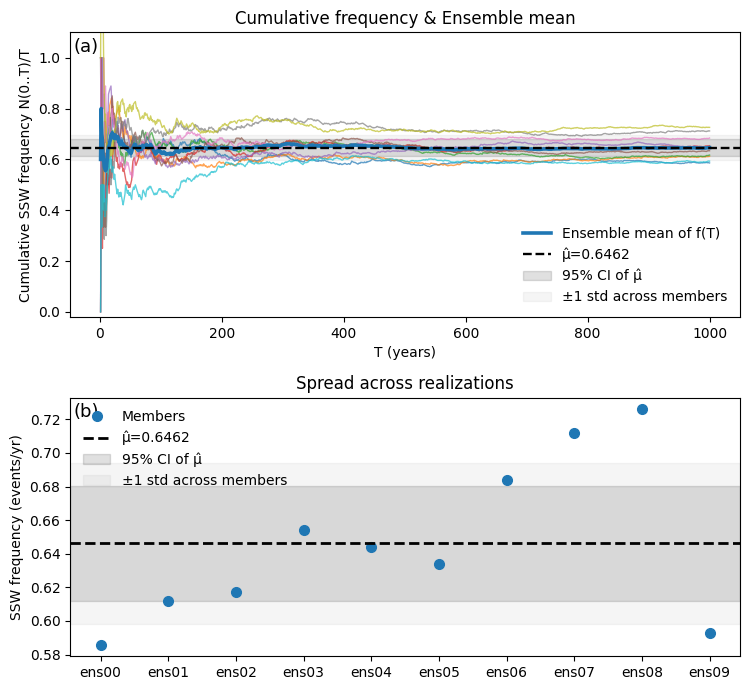

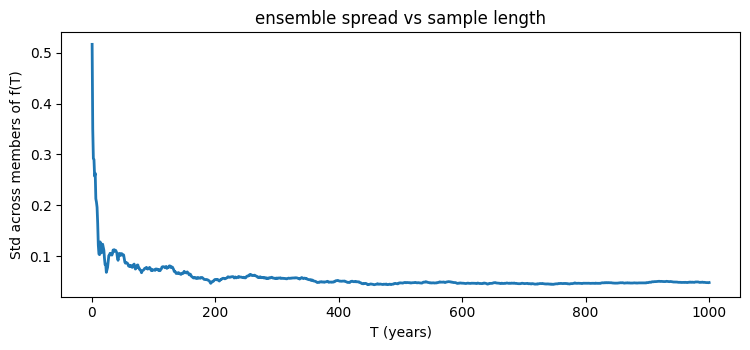


===== 500/500 stability check (160) =====
mean |Δ| = 0.0180 events/yr
min/max Δ = -0.0420 / 0.0400


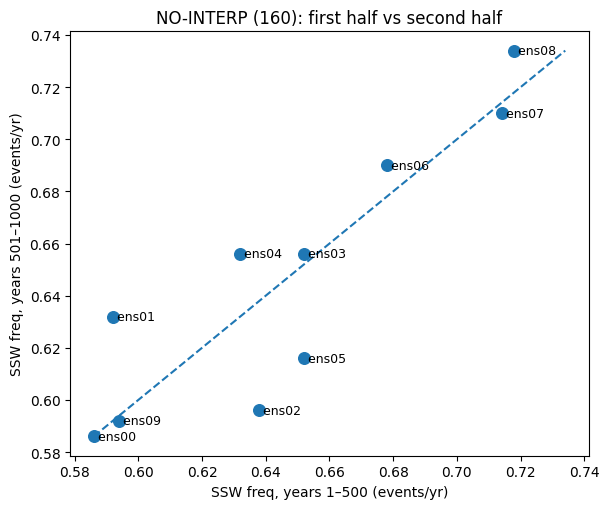

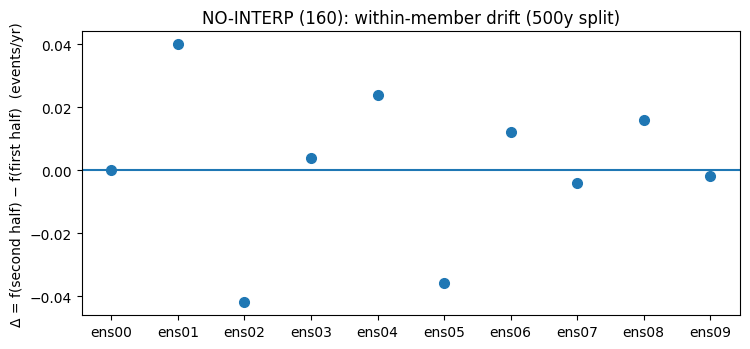

In [19]:
# ========= Ensemble mean uncertainty (this is "significance" for the mean) =========
mu = float(freq_160.mean())
s = float(freq_160.std(ddof=1)) if M > 1 else 0.0
se = s / np.sqrt(M) if M > 1 else 0.0
tcrit = float(student_t.ppf(0.5 + CONF_MEAN/2.0, df=max(M-1, 1))) if M > 1 else 0.0
ci_lo, ci_hi = mu - tcrit * se, mu + tcrit * se

print("\n===== Ensemble mean stats (160) =====")
print(f"M={M}, years/member={yr}")
print(f"mu_hat = {mu:.4f} events/yr")
print(f"between-member std s = {s:.4f}")
print(f"SE(mu_hat) = {se:.4f}")
print(f"{int(CONF_MEAN*100)}% CI for mu_hat = [{ci_lo:.4f}, {ci_hi:.4f}]  (t={tcrit:.3f})")
print(f"min/max = {freq_160.min():.4f} / {freq_160.max():.4f}")

# ========= Plot 1+2:  (panel a+b) =========
T = np.arange(1, yr + 1)
x = np.arange(M)

fig, axs = plt.subplots(2, 1, figsize=(7.6, 7.0), gridspec_kw={'height_ratios': [1.1, 1]})

# Panel (a): cumulative frequency
ax = axs[0]
for i in range(M):
    ax.plot(T, cum_160[i], lw=1, alpha=0.7)
ax.plot(T, cum_160.mean(axis=0), lw=2.6, label="Ensemble mean of f(T)")
ax.axhline(mu, color="k", ls="--", lw=1.7, label=f"μ̂={mu:.4f}")
ax.axhspan(ci_lo, ci_hi, color="k", alpha=0.12, label=f"{int(CONF_MEAN*100)}% CI of μ̂")
ax.axhspan(mu - s, mu + s, color="gray", alpha=0.08, label="±1 std across members")
ax.set_xlabel("T (years)")
ax.set_ylabel("Cumulative SSW frequency N(0..T)/T")
ax.set_title("Cumulative frequency & Ensemble mean")
ax.set_ylim(-0.02, 1.1)
# Subplot corner label
ax.text(0.005, 0.98, "(a)", transform=ax.transAxes, fontsize=13,  va='top', ha='left')
ax.legend(frameon=False)

# Panel (b): scatter across realizations
ax = axs[1]
ax.plot(x, freq_160, "o", ms=7, label="Members")
ax.axhline(mu, lw=2, color="k", ls="--", label=f"μ̂={mu:.4f}")
ax.axhspan(ci_lo, ci_hi, color="k", alpha=0.12, label=f"{int(CONF_MEAN*100)}% CI of μ̂")
ax.axhspan(mu - s, mu + s, color="gray", alpha=0.08, label="±1 std across members")
ax.set_xticks(x)
ax.set_xticklabels(ens_list)
ax.set_ylabel("SSW frequency (events/yr)")
ax.set_title("Spread across realizations")
# Subplot corner label
ax.text(0.005, 0.98, "(b)", transform=ax.transAxes, fontsize=13,  va='top', ha='left')
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("cumulative+spread_panel_ab.png")
plt.show()

# ========= Plot 3: std(f(T)) across ensemble vs T =========
plt.figure(figsize=(7.6, 3.6))
plt.plot(T, cum_160.std(axis=0, ddof=1), lw=2)
plt.xlabel("T (years)")
plt.ylabel("Std across members of f(T)")
plt.title("ensemble spread vs sample length")
plt.tight_layout()
plt.show()

# ========= Plot 4-5: 500/500 stability check =========
mid = yr // 2
f1 = counts_160[:, :mid].sum(axis=1) / float(mid)
f2 = counts_160[:, mid:].sum(axis=1) / float(yr - mid)
delta = f2 - f1

print("\n===== 500/500 stability check (160) =====")
print(f"mean |Δ| = {np.mean(np.abs(delta)):.4f} events/yr")
print(f"min/max Δ = {delta.min():.4f} / {delta.max():.4f}")

# Plot 4: first-half vs second-half
plt.figure(figsize=(6.2, 5.2))
lo = min(f1.min(), f2.min())
hi = max(f1.max(), f2.max())
plt.plot([lo, hi], [lo, hi], "--", lw=1.5)
plt.scatter(f1, f2, s=70)
for i, name in enumerate(ens_list):
    plt.text(f1[i], f2[i], f" {name}", fontsize=9, va="center")
plt.xlabel(f"SSW freq, years 1–{mid} (events/yr)")
plt.ylabel(f"SSW freq, years {mid+1}–{yr} (events/yr)")
plt.title("NO-INTERP (160): first half vs second half")
plt.tight_layout()
plt.show()

# Plot 5: delta dot plot
plt.figure(figsize=(7.6, 3.6))
plt.axhline(0.0, lw=1.5)
plt.plot(np.arange(M), delta, "o", ms=7)
plt.xticks(np.arange(M), ens_list)
plt.ylabel("Δ = f(second half) − f(first half)  (events/yr)")
plt.title("NO-INTERP (160): within-member drift (500y split)")
plt.tight_layout()
plt.show()

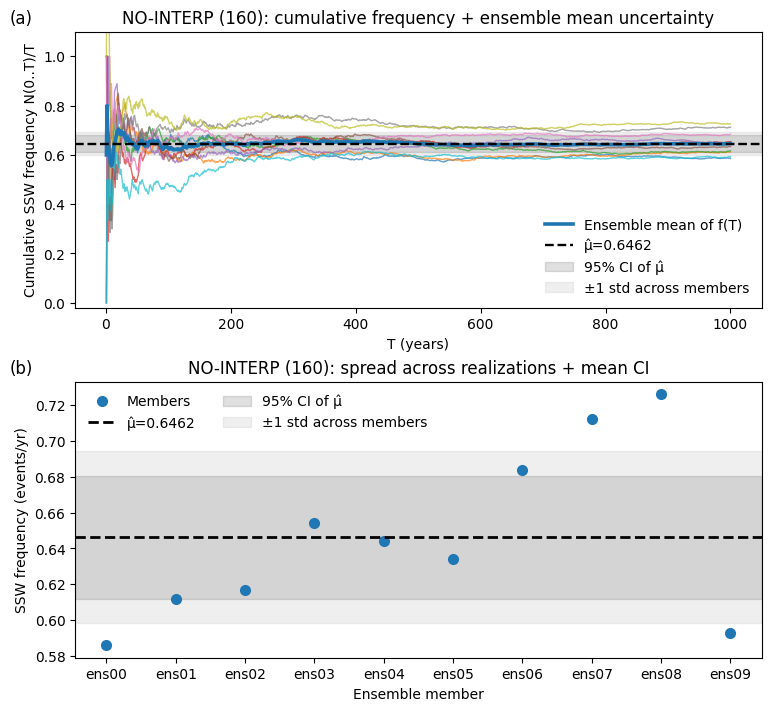

In [30]:
# ========= Combined Plot 1+2: panel (a) and (b) =========
T = np.arange(1, yr + 1)

fig, axes = plt.subplots(2, 1, figsize=(7.6, 7.0), constrained_layout=True)

# ---------------- Panel (a): cumulative frequency curves ----------------
ax = axes[0]
for i in range(M):
    ax.plot(T, cum_160[i], lw=1, alpha=0.7)

ax.plot(T, cum_160.mean(axis=0), lw=2.6, label="Ensemble mean of f(T)")
ax.axhline(mu, color="k", ls="--", lw=1.7, label=f"μ̂={mu:.4f}")
ax.axhspan(ci_lo, ci_hi, color="k", alpha=0.12,
           label=f"{int(CONF_MEAN*100)}% CI of μ̂")
ax.axhspan(mu - s, mu + s, color="gray", alpha=0.12,
           label="±1 std across members")

ax.set_xlabel("T (years)")
ax.set_ylabel("Cumulative SSW frequency N(0..T)/T")
ax.set_title("NO-INTERP (160): cumulative frequency + ensemble mean uncertainty")
ax.set_ylim(-0.02, 1.1)
ax.legend(frameon=False)

# panel label
ax.text(-0.095, 1.08, "(a)", transform=ax.transAxes,
        ha="left", va="top", fontsize=12)

# ---------------- Panel (b): scatter of member frequencies ----------------
ax = axes[1]
x = np.arange(M)

ax.plot(x, freq_160, "o", ms=7, label="Members")
ax.axhline(mu, lw=2, color="k", ls="--", label=f"μ̂={mu:.4f}")
ax.axhspan(ci_lo, ci_hi, color="k", alpha=0.12,
           label=f"{int(CONF_MEAN*100)}% CI of μ̂")
ax.axhspan(mu - s, mu + s, color="gray", alpha=0.12,
           label="±1 std across members")

ax.set_xticks(x)
ax.set_xticklabels(ens_list)
ax.set_ylabel("SSW frequency (events/yr)")
ax.set_xlabel("Ensemble member")
ax.set_title("NO-INTERP (160): spread across realizations + mean CI")
ax.legend(frameon=False, ncol=2)

# panel label
ax.text(-0.095, 1.08, "(b)", transform=ax.transAxes,
        ha="left", va="top", fontsize=12)

# save combined figure
fig.savefig("NO-INTERP_160_combined_ab.png", dpi=600, bbox_inches="tight")
plt.show()

=== 160-grid SSW frequency by 250y blocks (events/yr) ===
ens00:  0.592  0.580  0.620  0.552   (mean=0.586)
ens01:  0.596  0.588  0.616  0.648   (mean=0.612)
ens02:  0.632  0.644  0.568  0.624   (mean=0.617)
ens03:  0.616  0.688  0.624  0.688   (mean=0.654)
ens04:  0.620  0.644  0.736  0.576   (mean=0.644)
ens05:  0.664  0.640  0.556  0.676   (mean=0.634)
ens06:  0.664  0.692  0.664  0.716   (mean=0.684)
ens07:  0.736  0.692  0.660  0.760   (mean=0.712)
ens08:  0.748  0.688  0.716  0.752   (mean=0.726)
ens09:  0.584  0.604  0.568  0.616   (mean=0.593)


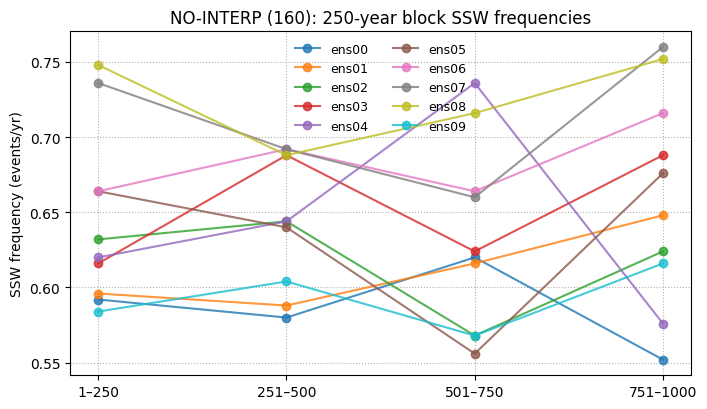

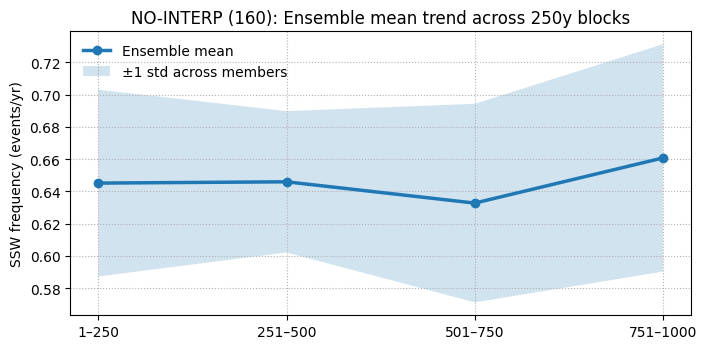

In [134]:
import numpy as np
import matplotlib.pyplot as plt

# 
# counts_160: shape (nEns, yr)  SSW160
# ens_list  : list[str]         e.g., ["ens00",...,"ens09"]
# yr        : int               e.g., 1000

counts = np.asarray(counts_160)
M, Y = counts.shape
assert Y == yr
assert len(ens_list) == M

# ===== 4 =====
edges = [0, 250, 500, 750, yr]  # 0-based, end exclusive
labels = ["1–250", "251–500", "501–750", "751–1000"]

freq_4 = np.zeros((M, 4), float)
for k in range(4):
    a, b = edges[k], edges[k+1]
    freq_4[:, k] = counts[:, a:b].sum(axis=1) / float(b - a)

# ===== 4=====
print("=== 160-grid SSW frequency by 250y blocks (events/yr) ===")
for i, name in enumerate(ens_list):
    vals = "  ".join([f"{freq_4[i,k]:.3f}" for k in range(4)])
    print(f"{name}:  {vals}   (mean={freq_4[i].mean():.3f})")

# ===== 14=====
x = np.arange(4)
plt.figure(figsize=(7.2, 4.2))
for i in range(M):
    plt.plot(x, freq_4[i], marker="o", linewidth=1.5, alpha=0.8, label=ens_list[i])
plt.xticks(x, labels)
plt.ylabel("SSW frequency (events/yr)")
plt.title("NO-INTERP (160): 250-year block SSW frequencies")
plt.grid(True, linestyle=":")
plt.legend(frameon=False, ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# ===== 2ensemble mean ± 1 std=====
mu = freq_4.mean(axis=0)
sd = freq_4.std(axis=0, ddof=1)

plt.figure(figsize=(7.2, 3.6))
plt.plot(x, mu, marker="o", linewidth=2.5, label="Ensemble mean")
plt.fill_between(x, mu - sd, mu + sd, alpha=0.2, label="±1 std across members")
plt.xticks(x, labels)
plt.ylabel("SSW frequency (events/yr)")
plt.title("NO-INTERP (160): Ensemble mean trend across 250y blocks")
plt.grid(True, linestyle=":")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()